# Homework 4: Unsupervised Learning

```{warning}
The submission of the homeworks has **NO** deadline. You can submit them whenever you want, on Virtuale. You are only required to upload it on Virtuale **BEFORE** your exam session, since the Homeworks will be a central part of the oral exam. 

You are asked to submit the homework as one of the two, following modalities:
* A PDF (or Word) document, containing screenshoots of code snippets, screeshots of the results generated by your code, and a brief comment on the obtained results.
* A Python Notebook (i.e. a `.ipynb` file), with cells containing the code required to solve the indicated exercises, alternated with a brief comment on the obtained results in the form of a markdown cell. We remark that the code **SHOULD NOT** be runned during the exam, but the student is asked to enter the exam with all the programs **already executed**, with the results clearly visible on the screen.

Joining the oral exam with a non-executed code OR without a PDF file with the obtained results visible on that, will cause the student to be rejected.
```

## Exercise 1: Compute the SVD of a Matrix & Verify the Reconstruction

1. Construct any non-square matrix $A \in \mathbb{R}^{m \times n}$ (e.g. $m=10$, $n=6$) with random or structured entries.
2. Compute its SVD:
   
   $$
   A = U\Sigma V^T.
   $$

3. Verify numerically that:
   
   $$
   A \approx U\Sigma V^T,
   \qquad
   \|A - U\Sigma V^T\|_F \approx 0.
   $$

4. Print and plot the singular values $\sigma_1,\dots,\sigma_{\min(m,n)}$.

5. Comment on why singular values appear in descending order, why small singular values correspond to “less important” directions, and why floating-point arithmetic makes exact zeros rare.


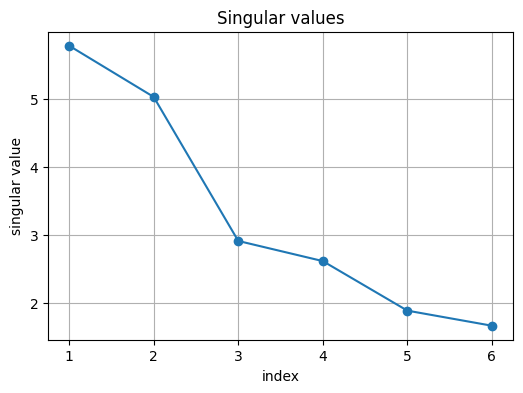

(10, 6) (10, 6) (6, 6) (6, 6)
6.898098183048788e-15
[5.78551301 5.03097617 2.90927485 2.61249327 1.8825643  1.66031666]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(8)
A = np.random.randn(10, 6)
U, s, VT = np.linalg.svd(A, full_matrices=False)
Sigma = np.diag(s)
A_rec = U @ Sigma @ VT
err = np.linalg.norm(A - A_rec, ord="fro")

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(s)+1), s, "o-")
plt.xlabel("index")
plt.ylabel("singular value")
plt.title("Singular values")
plt.grid()
plt.show()

print(A.shape, U.shape, Sigma.shape, VT.shape)
print(err)
print(s)


## Exercise 2: Best Rank-$k$ Approximation

1. Implement a function:
   
   $$
   A_k = \sum_{i=1}^k \sigma_i u_i v_i^T.
   $$

2. For several values of $k$, compute:
   
   $$
   E(k) = \|A - A_k\|_F.
   $$

3. Plot the approximation error $E(k)$ vs $k$.
4. Explain why SVD gives the *optimal* rank-$k$ approximation.


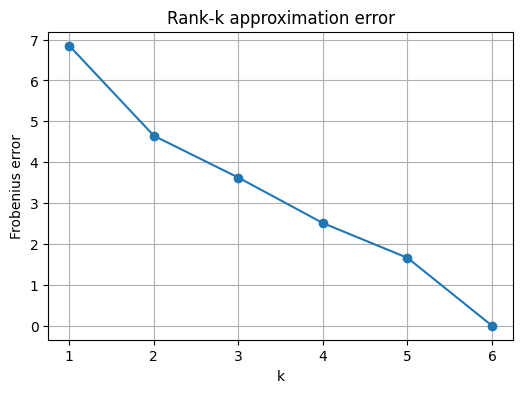

1 6.848388288066717
2 4.64647188199429
3 3.6229574668874363
4 2.51011946660418
5 1.6603166570390615
6 6.898098183048788e-15


In [2]:
import numpy as np
import matplotlib.pyplot as plt


def rank_k_approx(A, k):
    U, s, VT = np.linalg.svd(A, full_matrices=False)
    return U[:, :k] @ np.diag(s[:k]) @ VT[:k, :]

ks = np.arange(1, min(A.shape) + 1)
errors = []
for k in ks:
    Ak = rank_k_approx(A, k)
    errors.append(np.linalg.norm(A - Ak, ord="fro"))

plt.figure(figsize=(6, 4))
plt.plot(ks, errors, "o-")
plt.xlabel("k")
plt.ylabel("Frobenius error")
plt.title("Rank-k approximation error")
plt.grid()
plt.show()

for k, error in zip(ks, errors):
    print(k, error)


## Exercise 3: Image Compression with SVD

Using the `cameraman` image (as in the notes):

1. Load the image as a matrix $X \in \mathbb{R}^{512\times512}$.
2. Compute its SVD:
   
   $$
   X = U\Sigma V^T.
   $$

3. For $k \in \{5, 20, 50, 100, 200\}$:
   - Compute the rank-$k$ approximation $X_k$,
   - Plot each reconstructed image,
   - Compute the compression factor:
     
     $$
     c_k
     = 1 - \frac{k(m+n+1)}{mn}.
     $$

   - Plot reconstruction error vs $k$,
   - Plot compression factor vs $k$.

4. Comment on:
   - How visual quality improves with $k$,
   - Why most of the “energy” is contained in the first singular values,
   - The trade-off between compression and fidelity,
   - The connection between SVD and optimal low-rank approximation.


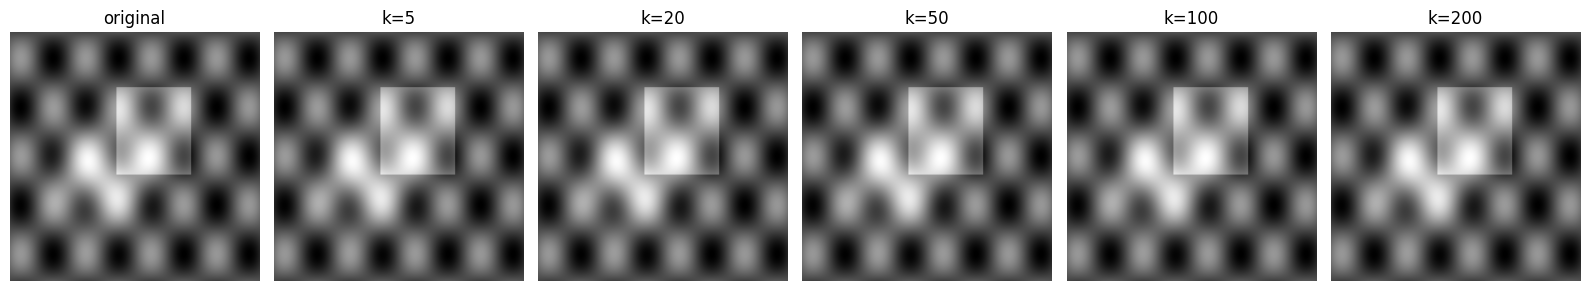

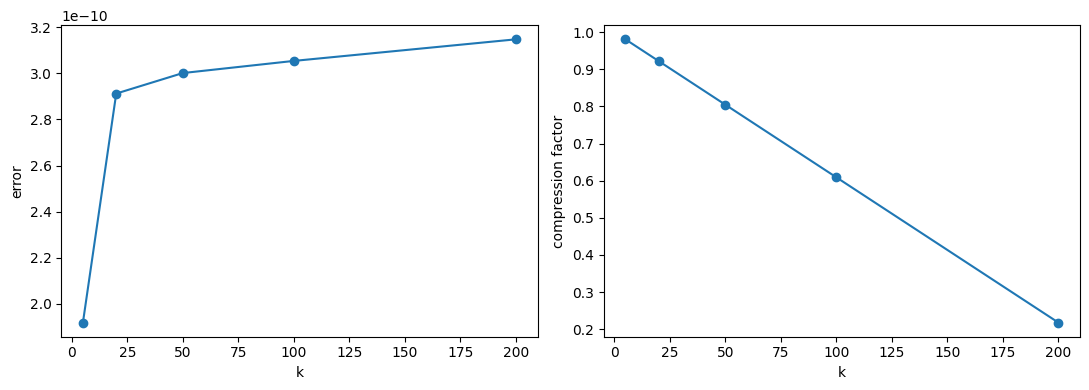

5 1.9194892685763467e-10 0.9804496765136719
20 2.9118613069067604e-10 0.9217987060546875
50 3.000751301556651e-10 0.8044967651367188
100 3.0533510432995813e-10 0.6089935302734375
200 3.146867432620047e-10 0.217987060546875


In [3]:
import numpy as np
import matplotlib.pyplot as plt


def load_image():
    try:
        from skimage import data
        return data.camera().astype(float)
    except Exception:
        x = np.linspace(-1, 1, 512)
        y = np.linspace(-1, 1, 512)
        X, Y = np.meshgrid(x, y)
        img = 140 + 70*np.exp(-8*((X+0.25)**2 + (Y-0.15)**2)) + 40*np.sin(12*X)*np.cos(8*Y)
        img += 35*((X > -0.15) & (X < 0.45) & (Y > -0.55) & (Y < 0.15))
        return np.clip(img, 0, 255)

X_img = load_image()
U_img, s_img, VT_img = np.linalg.svd(X_img, full_matrices=False)
ks = [5, 20, 50, 100, 200]
errors = []
compressions = []
m, n = X_img.shape
fig, axes = plt.subplots(1, len(ks)+1, figsize=(16, 4))
axes[0].imshow(X_img, cmap="gray")
axes[0].set_title("original")
axes[0].axis("off")
for ax, k in zip(axes[1:], ks):
    Xk = U_img[:, :k] @ np.diag(s_img[:k]) @ VT_img[:k, :]
    errors.append(np.linalg.norm(X_img - Xk, ord="fro"))
    compressions.append(1 - k*(m+n+1)/(m*n))
    ax.imshow(np.clip(Xk, 0, 255), cmap="gray")
    ax.set_title(f"k={k}")
    ax.axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ks, errors, "o-")
axes[0].set_xlabel("k")
axes[0].set_ylabel("error")
axes[1].plot(ks, compressions, "o-")
axes[1].set_xlabel("k")
axes[1].set_ylabel("compression factor")
plt.tight_layout()
plt.show()

for k, error, compression in zip(ks, errors, compressions):
    print(k, error, compression)


## Exercise 5: PCA + Clustering on a Real Dataset

Use the MNIST Kaggle dataset: https://www.kaggle.com/datasets/animatronbot/mnist-digit-recognizer.

To reduce computational burden, **filter only digits 3 and 4** exactly as in the teaching notes.

Do as follows:
1. Load the CSV file into memory (you may use NumPy or pandas).
2. Split into training and test sets.
3. Center the training data:
   
   $$
   X_{c,\text{train}} = X_{\text{train}} - c(X_{\text{train}}).
   $$

4. Compute the reduced SVD of the centered training data.
5. Choose $k=2$ principal components.
6. Project:
   - $Z_{\text{train}} = X_{c,\text{train}} V_2$,
   - $Z_{\text{test}} = X_{c,\text{test}} V_2$.
7. Plot:
   - Scatterplot of $Z_{\text{train}}$ colored by labels (3 vs 4),
   - Scatterplot of $Z_{\text{test}}$ overlaid in the same plot.

8. Repeat with digits 5 vs 8, or 1 vs 7 and discuss on the different results. 
 
9.  Finally, try $k=3$ and use a 3D scatterplot.


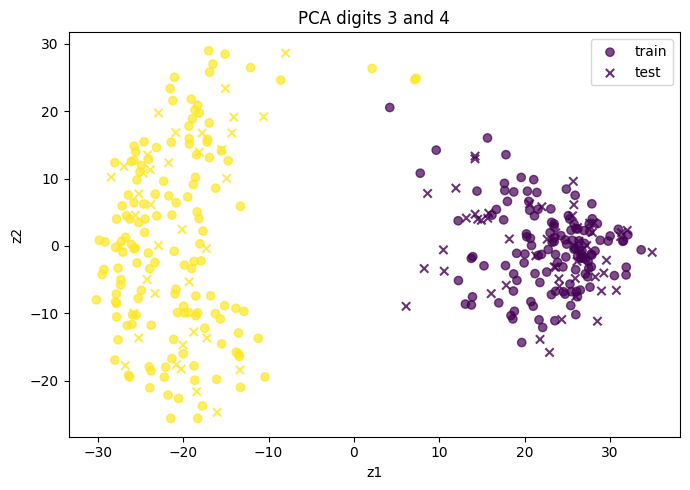

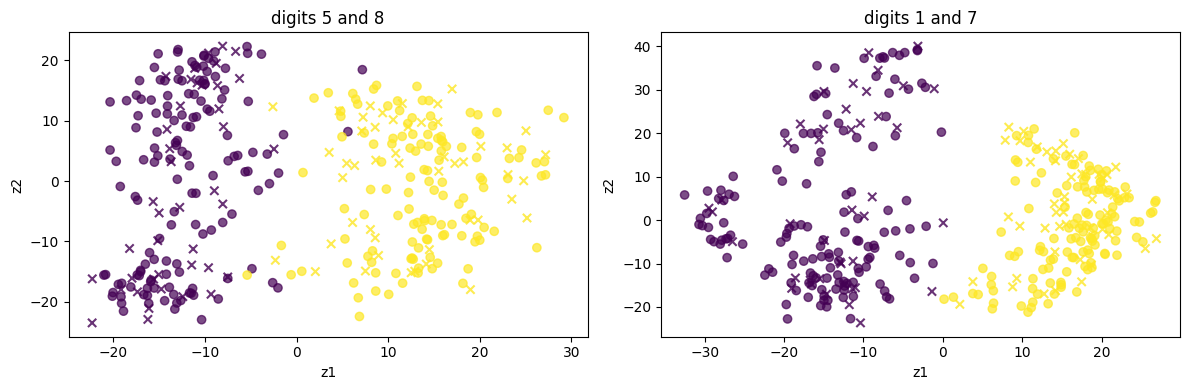

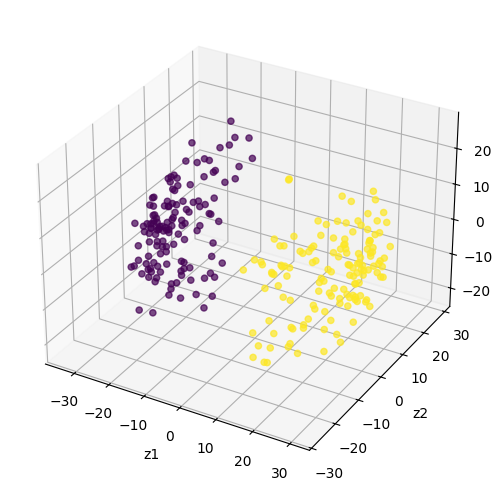

(273, 2) (91, 2)
[373.30884038 180.90209588 142.93584403 128.91923615 127.6119411
 105.66111763  93.40251909  81.60852761  78.74600225  75.93523141]


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.datasets import load_digits
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(9)

def load_digit_data():
    paths = [Path("data/MNIST.csv"), Path("data/train.csv"), Path("MNIST.csv"), Path("train.csv")]
    for path in paths:
        if path.exists():
            df = pd.read_csv(path)
            if "label" in df.columns:
                y = df["label"].values
                X = df.drop("label", axis=1).values
            else:
                data = df.values
                if data.shape[1] == 785 and np.all(np.isin(data[:, 0], np.arange(10))):
                    y = data[:, 0]
                    X = data[:, 1:]
                else:
                    y = data[:, -1]
                    X = data[:, :-1]
            return X.astype(float), y.astype(int)
    digits = load_digits()
    return digits.data.astype(float), digits.target.astype(int)

def split_data(X, y, train_ratio=0.75):
    idx = np.random.permutation(len(y))
    n_train = int(train_ratio*len(y))
    train_idx = idx[:n_train]
    test_idx = idx[n_train:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def pca_digits(pair=(3, 4), k=2):
    X_all, y_all = load_digit_data()
    mask = (y_all == pair[0]) | (y_all == pair[1])
    X_pair = X_all[mask]
    y_pair = y_all[mask]
    X_train, X_test, y_train, y_test = split_data(X_pair, y_pair)
    cX = X_train.mean(axis=0, keepdims=True)
    Xc_train = X_train - cX
    Xc_test = X_test - cX
    U, s, VT = np.linalg.svd(Xc_train, full_matrices=False)
    P = VT[:k].T
    Z_train = Xc_train @ P
    Z_test = Xc_test @ P
    return Z_train, Z_test, y_train, y_test, P, cX, s

Z_train, Z_test, y_train, y_test, P, cX, s = pca_digits((3, 4), k=2)
plt.figure(figsize=(7, 5))
plt.scatter(Z_train[:,0], Z_train[:,1], c=y_train, alpha=0.7, label="train")
plt.scatter(Z_test[:,0], Z_test[:,1], c=y_test, marker="x", alpha=0.8, label="test")
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("PCA digits 3 and 4")
plt.legend()
plt.tight_layout()
plt.show()

pairs = [(5, 8), (1, 7)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pair in zip(axes, pairs):
    Za, Zb, ya, yb, P_pair, c_pair, s_pair = pca_digits(pair, k=2)
    ax.scatter(Za[:,0], Za[:,1], c=ya, alpha=0.7)
    ax.scatter(Zb[:,0], Zb[:,1], c=yb, marker="x", alpha=0.8)
    ax.set_title(f"digits {pair[0]} and {pair[1]}")
    ax.set_xlabel("z1")
    ax.set_ylabel("z2")
plt.tight_layout()
plt.show()

Z3_train, Z3_test, y3_train, y3_test, P3, c3, s3 = pca_digits((3, 4), k=3)
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(Z3_train[:,0], Z3_train[:,1], Z3_train[:,2], c=y3_train, alpha=0.7)
ax.set_xlabel("z1")
ax.set_ylabel("z2")
ax.set_zlabel("z3")
plt.tight_layout()
plt.show()

print(Z_train.shape, Z_test.shape)
print(s[:10])


## Exercise 6: Classification After PCA: Linear Classifier and Centroid Classifier

In this exercise, you will build two simple classifiers **after projecting the data with PCA**:

1. **A linear classifier on 2D PCA features**,  
2. **A PCA-centroid classifier** that assigns each test point to the closest class centroid in the reduced space.

You will perform all experiments on the same Kaggle dataset used previously: https://www.kaggle.com/datasets/animatronbot/mnist-digit-recognizer, filtering only digits 3 and 4, as you did in the previosu exercise.

The aim of this exercise is to connect dimensionality reduction with classification and illustrates how PCA can be used not only for visualization, but also as a preprocessing tool for machine learning pipelines.

### Step 1: PCA Projection

Use exactly the same PCA workflow as in Exercise 6:

1. Load and split digits {3,4} into `train` and `test`.
2. Center the training data:
   
   $$
   X_{c,\text{train}} = X_{\text{train}} - c(X_{\text{train}}).
   $$

3. Compute the reduced SVD:
   
   $$
   X_{c,\text{train}} = U \Sigma V^T.
   $$

4. Take the first two principal directions:
   
   $$
   P = V_2 \in \mathbb{R}^{d \times 2}.
   $$

5. Project:
   
   $$
   Z_{\text{train}} = X_{c,\text{train}} P,
   \qquad
   Z_{\text{test}} = (X_{\text{test}} - c(X_{\text{train}}))\, P.
   $$


You will now use these 2D representations $Z_{\text{train}}$ and $Z_{\text{test}}$ for classification.

### Step 2: Fit a linear classifier

1. Use the logistic regression model:

    $$
    f_{\Theta}(z) = \sigma(\Theta^T z), \qquad z \in \mathbb{R}^2,
    $$

    with sigmoid and binary cross-entropy loss, and train the model using SGD.

2. Once trained:
   1. Plot the PCA-reduced training data in 2D,
   2. Plot the decision boundary defined by:
      
      $$
      \Theta^T z = 0 \quad \Rightarrow \quad \text{boundary line}.
      $$


3.  Compute, on the test set:

    - Accuracy,
    - Precision and Recall,
    - Confusion matrix.

### Step 3: PCA-Centroid Classifier (Nearest-Centroid in PCA Space)

This classifier does **not** use a linear model. It relies purely on geometry in the reduced PCA space.

1. For each class $c\in\{3,4\}$, compute the centroid in PCA space:

    $$
    \mu_c = \frac{1}{|\mathcal{D}_c|}\sum_{z_i \in \mathcal{D}_c} z_i.
    $$

    Plot both centroids $\mu_3$ and $\mu_4$ in the PCA plane.

2. Given a test sample $x\in\mathbb{R}^d$:

   1. Project it:
      
      $$
      z = (x - c(X_{\text{train}}))\, P.
      $$

   2. Compute distances:
      
      $$
      d_3 = \|z - \mu_3\|_2,\qquad
      d_4 = \|z - \mu_4\|_2.
      $$

   3. Assign:
      
      $$
      \hat y = \arg\min_{c\in\{3,4\}} d_c.
      $$


    This is the **nearest-centroid classifier in PCA space**.

3.  Compute, on the test set:

    - Accuracy,
    - Precision and Recall,
    - Confusion matrix.

    Plot the test points with colors given by classification results.

### Step 4: Compare accuracy and error patterns

1. Compare linear classifier on PCA features vs centroid classifier in PCA space.

2. On the PCA scatterplot, plot:

   - the linear boundary,
   - the two centroids,
   - misclassified test samples highlighted in red.

3. Repeat by changing the digits in $\{ (1,7), (5,8), (2,3) \}$ and observe how class similarity influences:
   - the cluster shape,
   - centroid separation,
   - decision boundaries.


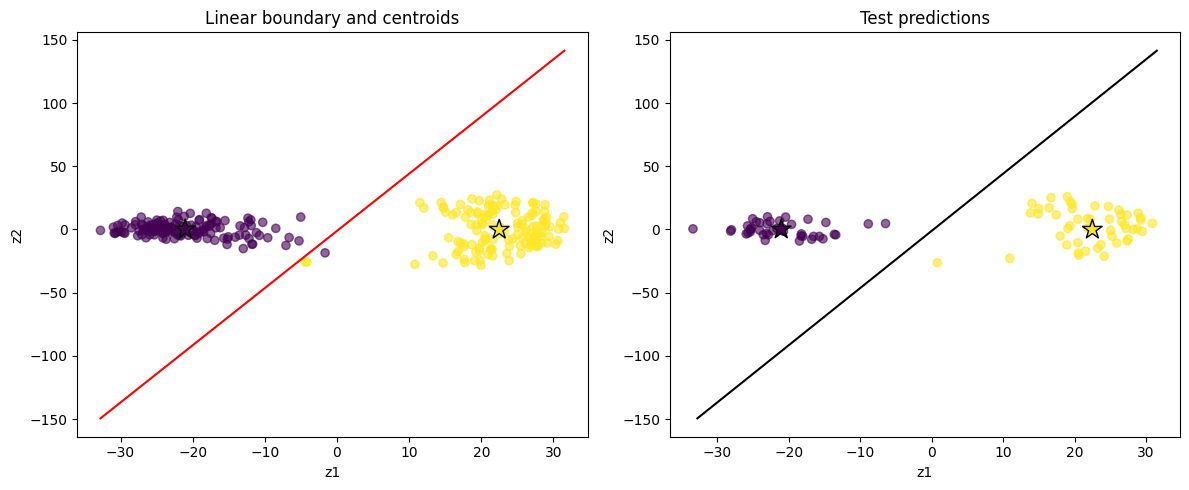

linear (1.0, 1.0, 1.0, (49, 0, 0, 42))
centroid (1.0, 1.0, 1.0, (49, 0, 0, 42))
(1, 7) linear (1.0, 1.0, 1.0, (48, 0, 0, 43)) centroid (1.0, 1.0, 1.0, (48, 0, 0, 43))
(5, 8) linear (1.0, 1.0, 1.0, (43, 0, 0, 46)) centroid (1.0, 1.0, 1.0, (43, 0, 0, 46))
(2, 3) linear (1.0, 1.0, 1.0, (45, 0, 0, 45)) centroid (0.9777777777777777, 0.9777777777777777, 0.9777777777777777, (44, 1, 1, 44))


In [5]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(z):
    return np.where(z >= 0, 1/(1 + np.exp(-z)), np.exp(z)/(1 + np.exp(z)))

def bce(theta, X, y, eps=1e-10):
    p = np.clip(sigmoid(X @ theta), eps, 1 - eps)
    return -(y*np.log(p) + (1-y)*np.log(1-p)).mean()

def grad_bce(theta, X, y):
    return X.T @ (sigmoid(X @ theta) - y)/len(y)

def metric_values(pred, y):
    pred = pred.astype(int).reshape(-1, 1)
    y = y.astype(int).reshape(-1, 1)
    tp = int(np.sum((pred == 1) & (y == 1)))
    fp = int(np.sum((pred == 1) & (y == 0)))
    fn = int(np.sum((pred == 0) & (y == 1)))
    tn = int(np.sum((pred == 0) & (y == 0)))
    acc = (tp + tn)/(tp + tn + fp + fn)
    prec = tp/(tp + fp) if tp + fp > 0 else 0
    rec = tp/(tp + fn) if tp + fn > 0 else 0
    return acc, prec, rec, (tp, fp, fn, tn)

def train_pca_logistic(Z_train, y_train, positive_label, lr=0.05, epochs=300, batch_size=32):
    X_lr = np.column_stack([np.ones(len(Z_train)), Z_train])
    y_bin = (y_train == positive_label).astype(int).reshape(-1, 1)
    theta = np.zeros((X_lr.shape[1], 1))
    n = len(y_bin)
    for epoch in range(epochs):
        idx = np.random.permutation(n)
        for start in range(0, n, batch_size):
            batch = idx[start:start + batch_size]
            theta = theta - lr*grad_bce(theta, X_lr[batch], y_bin[batch])
    return theta

def run_pca_classifiers(pair):
    Z_train, Z_test, y_train, y_test, P, cX, s = pca_digits(pair, k=2)
    positive = pair[1]
    theta = train_pca_logistic(Z_train, y_train, positive)
    X_test_lr = np.column_stack([np.ones(len(Z_test)), Z_test])
    pred_lr = np.where(sigmoid(X_test_lr @ theta) >= 0.5, positive, pair[0])
    mu0 = Z_train[y_train == pair[0]].mean(axis=0)
    mu1 = Z_train[y_train == pair[1]].mean(axis=0)
    d0 = np.linalg.norm(Z_test - mu0, axis=1)
    d1 = np.linalg.norm(Z_test - mu1, axis=1)
    pred_centroid = np.where(d1 < d0, pair[1], pair[0])
    return Z_train, Z_test, y_train, y_test, theta, mu0, mu1, pred_lr, pred_centroid

Z_train, Z_test, y_train, y_test, theta, mu3, mu4, pred_lr, pred_centroid = run_pca_classifiers((3, 4))
y_test_bin = (y_test == 4).astype(int).reshape(-1, 1)
lr_bin = (pred_lr == 4).astype(int).reshape(-1, 1)
centroid_bin = (pred_centroid == 4).astype(int).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(Z_train[:,0], Z_train[:,1], c=y_train, alpha=0.6)
xx = np.linspace(Z_train[:,0].min(), Z_train[:,0].max(), 200)
yy = -(theta[0,0] + theta[1,0]*xx)/theta[2,0]
axes[0].plot(xx, yy, color="red")
axes[0].scatter([mu3[0], mu4[0]], [mu3[1], mu4[1]], c=[3, 4], marker="*", s=220, edgecolors="black")
axes[0].set_title("Linear boundary and centroids")
axes[0].set_xlabel("z1")
axes[0].set_ylabel("z2")
mis = pred_lr.ravel() != y_test
axes[1].scatter(Z_test[:,0], Z_test[:,1], c=pred_lr.ravel(), alpha=0.6)
axes[1].scatter(Z_test[mis,0], Z_test[mis,1], facecolors="none", edgecolors="red", s=90)
axes[1].plot(xx, yy, color="black")
axes[1].scatter([mu3[0], mu4[0]], [mu3[1], mu4[1]], c=[3, 4], marker="*", s=220, edgecolors="black")
axes[1].set_title("Test predictions")
axes[1].set_xlabel("z1")
axes[1].set_ylabel("z2")
plt.tight_layout()
plt.show()

print("linear", metric_values(lr_bin, y_test_bin))
print("centroid", metric_values(centroid_bin, y_test_bin))
for pair in [(1, 7), (5, 8), (2, 3)]:
    Za, Zb, ya, yb, th, m0, m1, plr, pc = run_pca_classifiers(pair)
    yb_bin = (yb == pair[1]).astype(int).reshape(-1, 1)
    plr_bin = (plr == pair[1]).astype(int).reshape(-1, 1)
    pc_bin = (pc == pair[1]).astype(int).reshape(-1, 1)
    print(pair, "linear", metric_values(plr_bin, yb_bin), "centroid", metric_values(pc_bin, yb_bin))
